In addition to demonstrating a deep learning approach to predicting STEM/quantum pathway readiness, this notebook is designed as a small proof-of-concept for aligning K–12 standards. The feature set and modeling task connect to CSTA K–12 Computer Science Standards in “Data and Analysis,” national K–12 data science learning progressions, and Q–12 quantum education efforts that call for coherent pathways from foundational CS/data skills into quantum literacy. The quantum pathway labels are interpreted as readiness tiers that can be associated with specific standards-aligned learning experiences (for example, data-rich investigations and introductory quantum simulations) in future curriculum design work.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Path to dataset files: /kaggle/input/student-performance-data-set


In [2]:
import os
import pandas as pd

# List contents of the downloaded directory
print(os.listdir(path))

['student-por.csv']


In [3]:
# Adjust filename to 'student-por.csv' based on the directory listing
csv_file_path = os.path.join(path, 'student-por.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
def map_pathway(g3):
    if g3 >= 15:
        return "High_STEM"
    elif g3 >= 10:
        return "Moderate_STEM"
    else:
        return "Support_STEM"

df["pathway_label"] = df["G3"].apply(map_pathway)

In [6]:
import numpy as np

# Quick sanity check of final grade distribution
print(df["G3"].describe())
print(df["G3"].value_counts().sort_index())

# Define a 3-class "quantum pathway readiness" label
def map_quantum_pathway(g3):
    if g3 >= 15:
        return "High_Quantum_Pathway"      # strong STEM/CS/data foundation
    elif g3 >= 10:
        return "Moderate_Quantum_Pathway"  # can benefit from structured support
    else:
        return "Support_Quantum_Pathway"   # needs foundational strengthening

df["pathway_label"] = df["G3"].apply(map_quantum_pathway)

# Inspect class balance
df["pathway_label"].value_counts(normalize=True).rename("proportion")

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


,proportion
pathway_label,
Moderate_Quantum_Pathway,0.644068
High_Quantum_Pathway,0.201849
Support_Quantum_Pathway,0.154083


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
# Drop G3 (final grade) and the derived label from features
X = df.drop(columns=["G3", "pathway_label"])
y = df["pathway_label"]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# One-hot encode categoricals for the baseline model
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Encode labels as integers for the neural network
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
input_dim = X_train.shape[1]

print("Input dimension:", input_dim)
print("Classes:", list(label_encoder.classes_))

Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Input dimension: 41
Classes: ['High_Quantum_Pathway', 'Moderate_Quantum_Pathway', 'Support_Quantum_Pathway']


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Convert to tensors
X_train_tf = tf.convert_to_tensor(X_train.values, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val.values, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test.values, dtype=tf.float32)

y_train_tf = tf.convert_to_tensor(y_train_enc, dtype=tf.int32)
y_val_tf = tf.convert_to_tensor(y_val_enc, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test_enc, dtype=tf.int32)

# Build baseline MLP
baseline_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,827 (54.01 KB)

 Trainable params: 13,827 (54.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
baseline_history = baseline_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5595 - loss: 0.9140 - val_accuracy: 0.6495 - val_loss: 0.7713
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7004 - loss: 0.7115 - val_accuracy: 0.7526 - val_loss: 0.6402
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7533 - loss: 0.6169 - val_accuracy: 0.7629 - val_loss: 0.5490
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7555 - loss: 0.5329 - val_accuracy: 0.7732 - val_loss: 0.4804
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8260 - loss: 0.4630 - val_accuracy: 0.8454 - val_loss: 0.4138
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8392 - loss: 0.4096 - val_accuracy: 0.8351 - val_loss: 0.3631
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8590 - loss: 0.3668 - val_accuracy: 0.8969 - val_loss: 0.3373
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8656 - loss: 0.3328 - val_accuracy: 0.9072 - va

In [10]:
# Compute class weights to handle imbalance and nod to equity goals
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_enc)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)
class_weights = {i: w for i, w in zip(classes, class_weights_array)}
class_weights

{np.int64(0): np.float64(1.644927536231884),
 np.int64(1): np.float64(0.5182648401826484),
 np.int64(2): np.float64(2.1619047619047618)}

In [11]:
improved_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_history = improved_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.4185 - loss: 1.2049 - val_accuracy: 0.4639 - val_loss: 0.9489
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5881 - loss: 0.6720 - val_accuracy: 0.6392 - val_loss: 0.8169
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7070 - loss: 0.5098 - val_accuracy: 0.7423 - val_loss: 0.7431
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7137 - loss: 0.4601 - val_accuracy: 0.7835 - val_loss: 0.6907
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7665 - loss: 0.4385 - val_accuracy: 0.8351 - val_loss: 0.6531
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7753 - loss: 0.3732 - val_accuracy: 0.8144 - val_loss: 0.6200
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8084 - loss: 0.3202 - val_accuracy: 0.8247 - val_loss: 0.5807
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8502 - loss: 0.2776 - val_accuracy: 0.8454 - v

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
=== Baseline MLP ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.938     0.750     0.833        20
Moderate_Quantum_Pathway      0.864     0.905     0.884        63
 Support_Quantum_Pathway      0.688     0.733     0.710        15

                accuracy                          0.847        98
               macro avg      0.830     0.796     0.809        98
            weighted avg      0.852     0.847     0.847        98



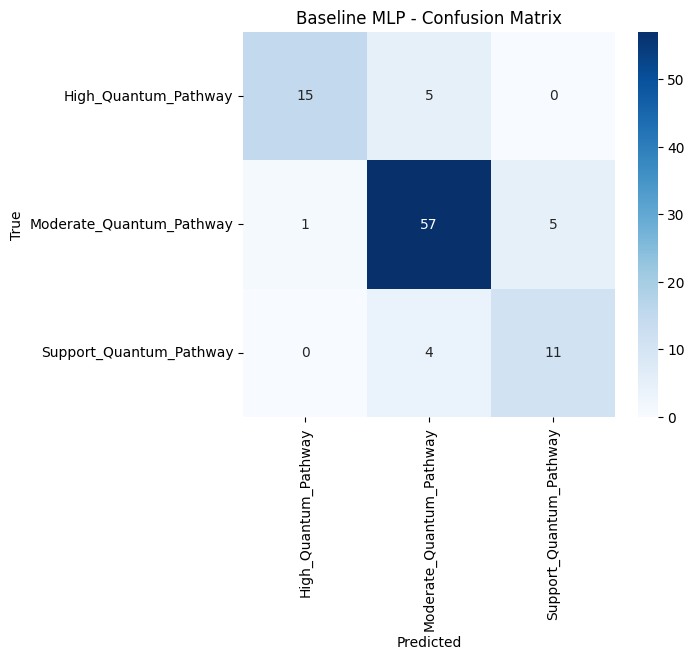

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step
=== Improved MLP (Class-Weighted) ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.850     0.850     0.850        20
Moderate_Quantum_Pathway      0.887     0.873     0.880        63
 Support_Quantum_Pathway      0.688     0.733     0.710        15

                accuracy                          0.847        98
               macro avg      0.808     0.819     0.813        98
            weighted avg      0.849     0.847     0.848        98



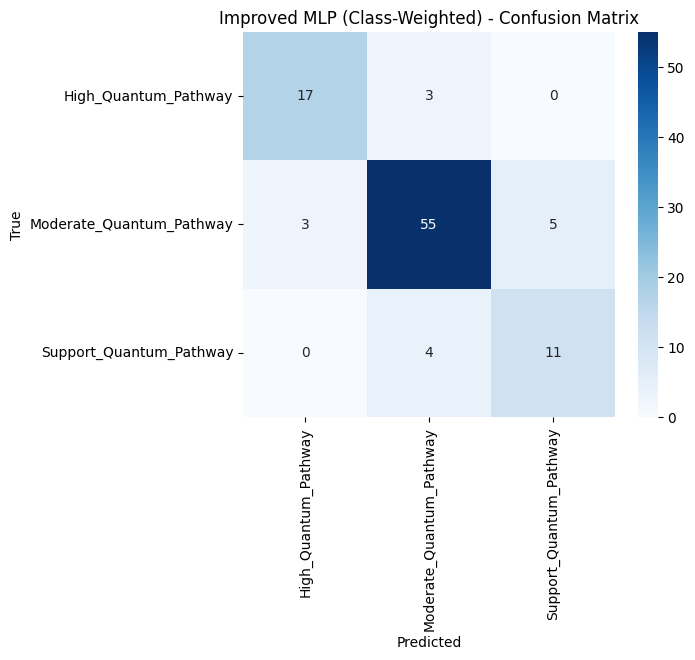

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X, y_true_enc, label_encoder, title="Model"):
    y_pred_probs = model.predict(X)
    y_pred_enc = y_pred_probs.argmax(axis=1)
    y_true = label_encoder.inverse_transform(y_true_enc)
    y_pred = label_encoder.inverse_transform(y_pred_enc)

    print(f"=== {title} ===")
    print(classification_report(y_true, y_pred, digits=3))

    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cmap="Blues")
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Evaluate on test set
evaluate_model(baseline_model, X_test_tf, y_test_enc, label_encoder, title="Baseline MLP")
evaluate_model(improved_model, X_test_tf, y_test_enc, label_encoder, title="Improved MLP (Class-Weighted)")

## Standards Alignment: CS, Data Science, and Quantum Literacy

This project is intentionally framed at the intersection of K–12 computer science, data science, and emerging quantum literacy standards.

**CSTA K–12 Computer Science Standards.**  
The modeling task and feature interpretation are aligned with CSTA’s “Data and Analysis” concept and associated performance expectations, particularly in the 3B band where students are expected to use data analysis tools to identify patterns in complex systems and evaluate models and simulations.[web:55][web:57] By training a neural network on authentic student performance data, the project embodies these expectations in a concrete example of using data and models to reason about educational outcomes.

**K–12 Data Science and Data Literacy Progressions.**  
The project design is informed by national efforts to articulate K–12 data literacy and data science progressions, which emphasize engaging students in collecting, visualizing, and interpreting data, as well as reasoning ethically about data use.[web:60][web:66] The use of student-level tabular data, derived pathway labels, and interpretable evaluation metrics mirrors key practices highlighted in these progressions: defining meaningful variables, constructing models, and reflecting on limitations.

**Q–12 Quantum Education and Quantum Literacy.**  
The pathway labels are interpreted as “quantum literacy readiness tiers” that connect existing CS and data science competencies to early quantum information science experiences. This aligns with the Q–12 Education Partnership and AAPT’s call for integrating modern quantum topics into high school physics, mathematics, and computer science through developmentally appropriate pathways and resources.[web:61][web:67] In the narrative, each readiness tier can be associated with example experiences (e.g., data-focused qubit simulations, introductory superposition/entanglement activities) that build toward QISE-related competencies.

### Conceptual Standards Mapping

| Layer in Project                      | Example Standards Connections                                                                 |
|--------------------------------------|------------------------------------------------------------------------------------------------|
| Tabular student features (grades, study time, absences, etc.) | CSTA Data & Analysis concepts and practices; students using data to reason about performance.[web:55][web:58] |
| Derived `pathway_label` (High/Moderate/Support Quantum Pathway) | K–12 data science progressions’ focus on modeling, classification, and interpreting data-driven groupings.[web:60][web:66] |
| Deep learning model training and evaluation | CSTA expectations around evaluating models and simulations, and using computational tools to analyze data.[web:55][web:57] |
| Interpretation as quantum literacy readiness tiers | Q–12 / AAPT guidance on scaffolding quantum information science concepts into high school STEM pathways.[web:61][web:67] |
| Example recommended experiences per tier (e.g., intro data science + qubit simulations) | Data science frameworks and Q–12 resources that outline age-appropriate QISE learning experiences and tools.[web:60][web:67] |